<a href="https://colab.research.google.com/github/Giihgallicchio/Programacao-em-Python-Data-Science/blob/main/Criando_Gr%C3%A1ficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Pacote de manipulação de dados
import pandas as pd

In [ ]:
# Pacote de visualização de dados
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('base_dados_vendas_tratada.csv', parse_dates=['dt_venda', 'dt_entrega'], index_col='dt_venda')
df.head()

,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final
dt_venda,,,,,,,,,,,,,
2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,3,2020-08-31 16:39:00,1212.3
2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.4,2,2020-06-11 13:59:00,284.8
2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,2,2019-03-28 09:44:00,808.2
2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,2,2019-09-20 09:22:00,3418.2
2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.0,2,2019-11-26 13:42:00,6398.0


In [ ]:
df['ano_mes'] = df.index.to_period('M') #Extraindo o M: Mês

In [ ]:
df.head()

,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,ano_mes
dt_venda,,,,,,,,,,,,,,
2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,3,2020-08-31 16:39:00,1212.3,2020-08
2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.4,2,2020-06-11 13:59:00,284.8,2020-06
2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,2,2019-03-28 09:44:00,808.2,2019-03
2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,2,2019-09-20 09:22:00,3418.2,2019-09
2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.0,2,2019-11-26 13:42:00,6398.0,2019-11


In [ ]:
df_vendas_mensal = df.groupby('ano_mes')['valor_final'].sum()

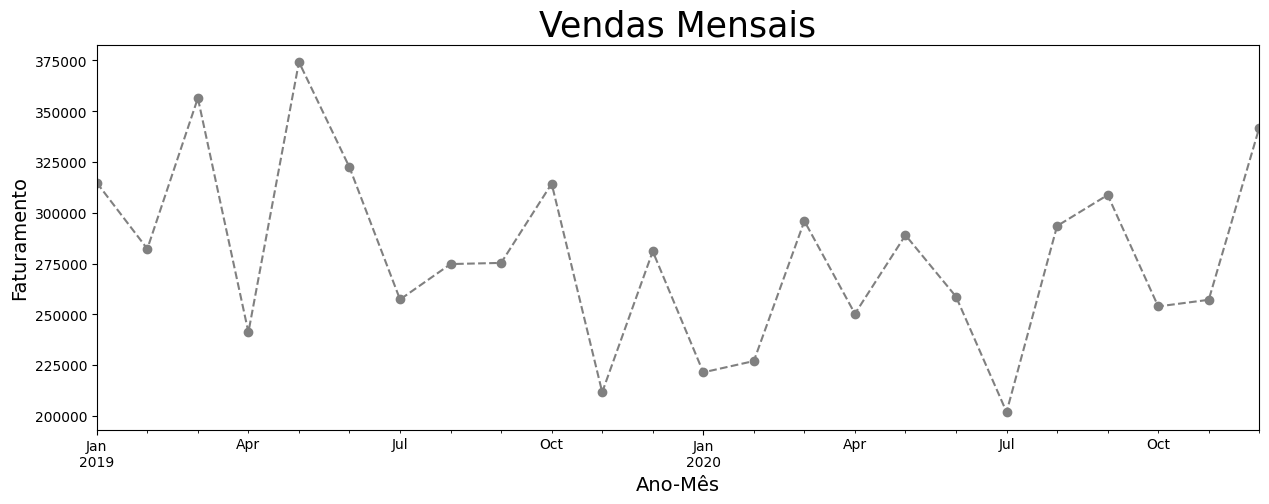

In [ ]:
df_vendas_mensal.plot(kind='line', figsize=(15,5), linestyle='--', color='grey', marker='o') # Criando um grafico/ tamanho do grafico / Cores / Mudando o estilo da linha / Adicionando marcadores
plt.title('Vendas Mensais', fontsize='25') # Adicionando titulo no grafico / aumenta o tamanho do titulo
plt.xlabel('Ano-Mês', fontsize='14')
plt.ylabel('Faturamento', fontsize='14');
#plt.xticks(rotation=45) # Mundando a trajetoria do Ano e Mês

In [ ]:
#Análise de Produtos
#Total de vendas por produto

df_vendas_produto = df.groupby('descricao_produto').agg(
      total_vendas = ('valor_final', 'sum'),
    total_quantidade = ('quantidade', 'sum')
)
df_vendas_produto = df_vendas_produto.sort_values(by='total_vendas', ascending=True)

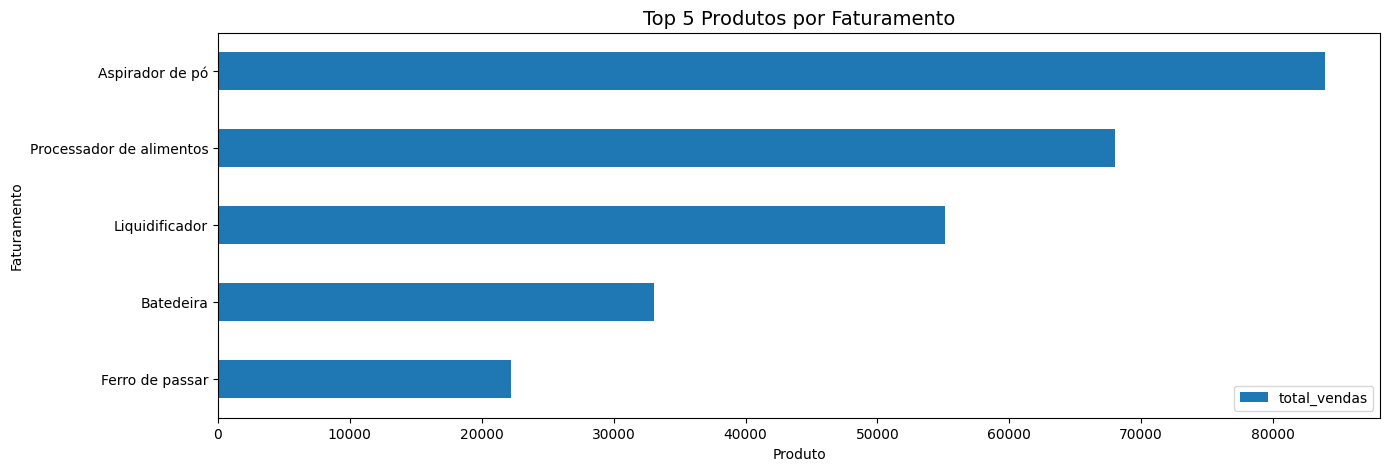

In [ ]:
df_vendas_produto.head(5).plot(kind='barh', y='total_vendas', figsize=(15,5));
plt.title('Top 5 Produtos por Faturamento', fontsize=(14))
plt.xlabel('Produto', fontsize=(10))
plt.ylabel('Faturamento', fontsize=(10));

In [ ]:
df_categoria_vendas = df.groupby('categoria')['valor_final'].sum()

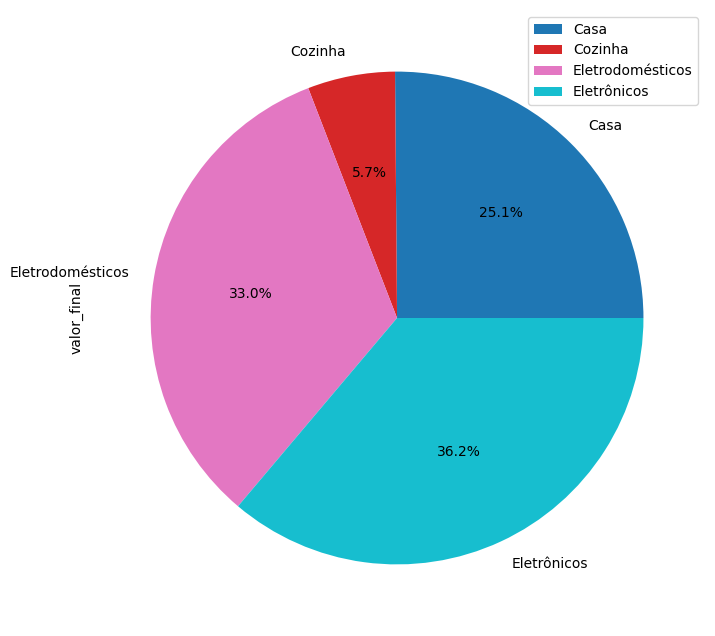

In [ ]:
plt.figure(figsize=(8,8))
df_categoria_vendas.plot.pie(autopct='%1.1f%%' ,cmap='tab10', legend=True);